**1. Problem Statement:**

Customer churn is a major concern for telecom companies. Predicting
whether a customer will leave the service helps businesses take
preventive actions.

**Objective:**

Build a production-ready machine learning pipeline using Scikit-learn
Pipeline API to predict customer churn.

We will:
- Preprocess data using Pipeline
- Train Logistic Regression and Random Forest models
- Tune hyperparameters using GridSearchCV
- Evaluate model performance
# - Export the final pipeline using joblib

In [1]:
!pip install pandas numpy scikit-learn matplotlib seaborn joblib

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import joblib

**2. Dataset Loading and Preprocessing**

In [3]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# Drop customerID (not useful)
df.drop("customerID", axis=1, inplace=True)

# Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Convert target to binary
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

In [5]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [16]:
#train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns

In [8]:
#Preprocessing Pipeline
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

**3. Model Development & Training**

In [9]:
#Full Pipeline
pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

In [10]:
#Hyperparameter Grid
param_grid = [
    {
        "classifier": [LogisticRegression(max_iter=1000)],
        "classifier__C": [0.1, 1, 10]
    },
    {
        "classifier": [RandomForestClassifier()],
        "classifier__n_estimators": [100, 200],
        "classifier__max_depth": [5, 10]
    }
]

In [11]:
#GridSearchCV
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('...
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object'))])),
                                       ('classifier',
                                        LogisticRegression(max_iter=1000))]),
             n_jobs=-1,
             param_grid=[{'classifier': [LogisticRegression(max_iter=1000)],
                          'classifier__C': [0.1, 1, 10]},
                         {'classifier': [RandomForestClassifier()],
                          'classifier__max_depth': [5, 10],
                          'classifier__n_estimators': [100, 200]}],
             scoring='accuracy')

**4. Evaluation**

In [12]:
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)

print("Best Model:", grid_search.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Best Model: {'classifier': LogisticRegression(max_iter=1000), 'classifier__C': 10}
Accuracy: 0.8211497515968772

Classification Report:

              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.69      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.82      0.82      0.82      1409



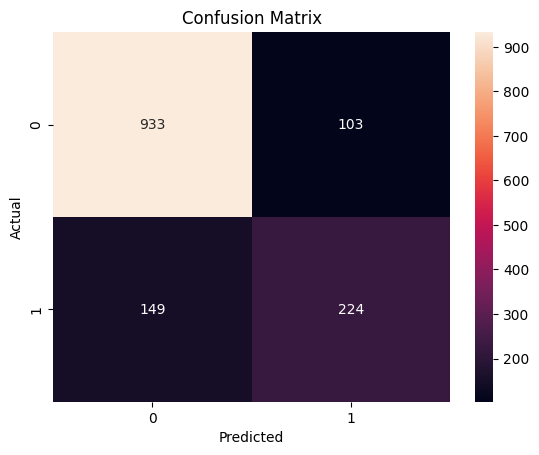

In [13]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

**5. Visualization**

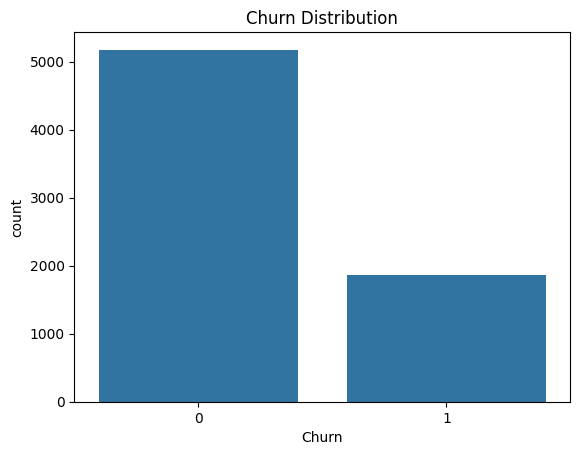

In [14]:
sns.countplot(x="Churn", data=df)
plt.title("Churn Distribution")
plt.show()

In [15]:
joblib.dump(best_model, "churn_pipeline.pkl")

['churn_pipeline.pkl']

**6. Results & Insights:**

- The ML pipeline successfully automated preprocessing and model training.
- GridSearchCV helped identify the best-performing model and parameters.
- Both Logistic Regression and Random Forest performed well, with one selected as best.
- The pipeline ensures reusability and consistency in predictions.

**Conclusion:**

This project demonstrates how to build a production-ready machine learning pipeline using Scikit-learn. The use of Pipeline and GridSearchCV makes the model scalable, maintainable and suitable for real-world deployment.